In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
uitslagen = []
etappes = np.arange(1,5)
for etappe_nr in etappes:
    excel_uitslag = pd.read_excel(f"../results/Uitslag etappe {etappe_nr}.xlsx", skiprows=3, index_col=2, usecols="H:Q")
    uitslag = excel_uitslag.rename(columns={"positie.1": f'positie.{etappe_nr}', "aantal punten.1": f"aantal punten.{etappe_nr}"})
    uitslagen.append(uitslag[[f'positie.{etappe_nr}', f'aantal punten.{etappe_nr}']])

In [4]:
alle_uitslagen = pd.concat(uitslagen, axis=1)

In [5]:
highlight = ['Timon van der Meulen']
poi = ['Lisanne Brosius', 'Gijs van Langen', 'Ger Westra', 'Joren Zandstra', 'Mark Arts', 'Rogier van Katwijk', 'Sander Jansen', 'Timon van der Meulen', 'Jorn van Breukelen', 'Marick Manrho']

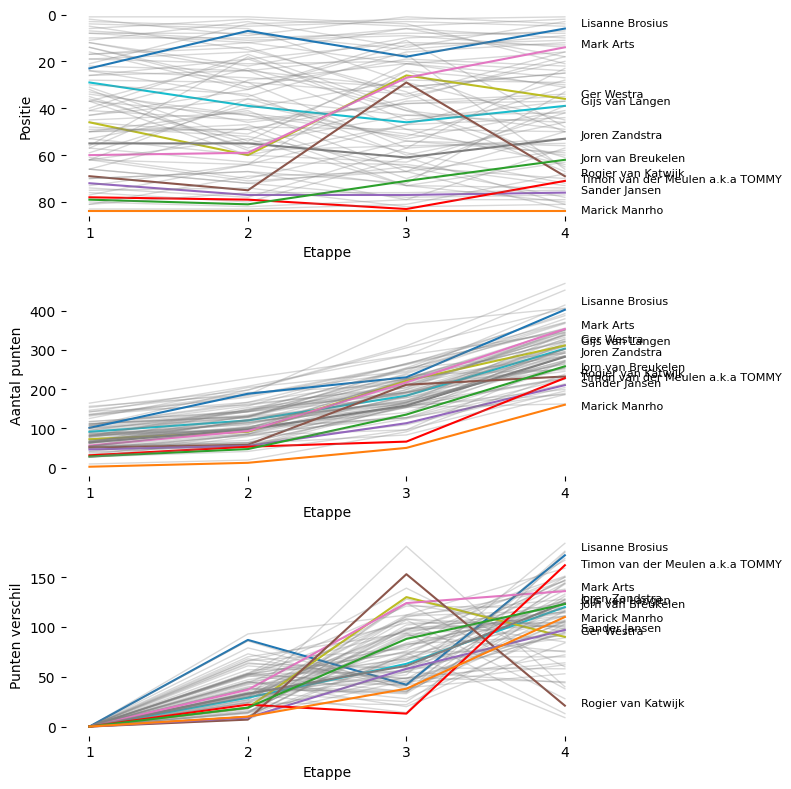

In [6]:
fig, axs = plt.subplots(3,1, figsize=(len(etappes)+4,8))
cm = plt.get_cmap('tab10')(np.linspace(0,1,10))
nth_highlight = 0
for deelnemer, rankings in alle_uitslagen.iterrows():
    positions = [val for name, val in rankings.items() if "positie" in name]
    points = [val for name, val in rankings.items() if "aantal punten" in name]
    diff_points = np.concatenate([[0], np.diff(points)])
    if deelnemer in highlight:
        color, alpha, lw = 'red', 1, 1.5
        axs[0].text(etappes[-1]+0.1, positions[-1] + (nth_highlight-5)/5, deelnemer + " a.k.a TOMMY", fontsize=8)
        axs[1].text(etappes[-1]+0.1, points[-1] - 3*(nth_highlight-5), deelnemer + " a.k.a TOMMY", fontsize=8)
        axs[2].text(etappes[-1]+0.1, diff_points[-1] - (nth_highlight-5), deelnemer + " a.k.a TOMMY", fontsize=8)
        nth_highlight += 1
    elif deelnemer in poi:
        color, alpha, lw = cm[-nth_highlight], 1, 1.5
        axs[0].text(etappes[-1]+0.1, positions[-1] + (nth_highlight-5)/5, deelnemer, fontsize=8)
        axs[1].text(etappes[-1]+0.1, points[-1] - 3*(nth_highlight-5), deelnemer, fontsize=8)
        axs[2].text(etappes[-1]+0.1, diff_points[-1] - (nth_highlight-5), deelnemer, fontsize=8)
        nth_highlight += 1
    else:
        color, alpha, lw = 'grey', 0.3, 1
        
    axs[0].plot(etappes, positions, color=color, alpha=alpha, linewidth=lw)
    axs[1].plot(etappes, points, color=color, alpha=alpha, linewidth=lw)
    axs[2].plot(etappes, diff_points, color=color, alpha=alpha, linewidth=lw)

axs[0].set_ylim(86,0)
axs[0].set_xlabel("Etappe")
axs[0].set_xticks(etappes)
axs[0].set_ylabel("Positie")

axs[1].set_xlabel("Etappe")
axs[1].set_xticks(etappes)
axs[1].set_ylabel("Aantal punten")

axs[2].set_xlabel('Etappe')
axs[2].set_xticks(etappes)
axs[2].set_ylabel("Punten verschil")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.savefig("Rankings.jpg")
plt.show()

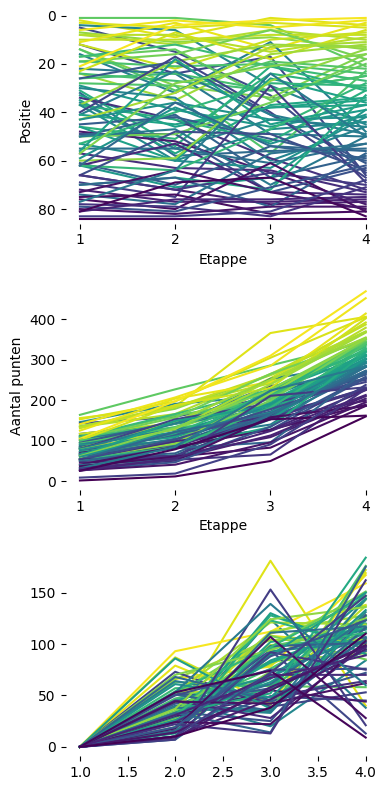

In [7]:
fig, axs = plt.subplots(3,1, figsize=(len(etappes),8))
cm = plt.get_cmap('viridis')

max_points = alle_uitslagen['aantal punten.4'].max()
min_position = alle_uitslagen['positie.4'].max()

for deelnemer, rankings in alle_uitslagen.iterrows():
    positions = [val for name, val in rankings.items() if "positie" in name]
    points = [val for name, val in rankings.items() if "aantal punten" in name]
    diff_points = np.concatenate([[0], np.diff(points)])
    color = cm(np.abs(positions[-1]-min_position)/min_position)
    axs[0].plot(etappes, positions, color=color)
    axs[1].plot(etappes, points, color=color)
    axs[2].plot(etappes, diff_points, color=color)

axs[0].set_ylim(86,0)
axs[0].set_xlabel("Etappe")
axs[0].set_xticks(etappes)
axs[0].set_ylabel("Positie")

axs[1].set_xlabel("Etappe")
axs[1].set_xticks(etappes)
axs[1].set_ylabel("Aantal punten")

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()